In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Import library yang dibutuhkan
import pandas as pd
import numpy as np

# ==============================================================================
# TAHAP 2: MEMUAT DATASET
# ==============================================================================
print("Memuat data dari Google Drive...")

# ⚠️ PENTING: Ubah path ini sesuai dengan lokasi file CSV-mu di Google Drive!
# Contoh: Jika file ada di folder "Magang_HCI", path-nya jadi '/content/drive/MyDrive/Magang_HCI/application_train.csv'
file_path = '/content/drive/MyDrive/Data Project/Rakamin Home kredit/application_train.csv'

try:
    df = pd.read_csv(file_path)
    print(f"✅ Data berhasil dimuat! Ukuran awal: {df.shape[0]} baris, {df.shape[1]} kolom.\n")
except FileNotFoundError:
    print("❌ ERROR: File tidak ditemukan. Pastikan path (jalur file) di atas sudah benar.")
    raise # Menghentikan program jika file tidak ada

Memuat data dari Google Drive...
✅ Data berhasil dimuat! Ukuran awal: 307511 baris, 122 kolom.



**PROSES DATA CLEANSING**

In [4]:
# ==============================================================================
# TAHAP 3: PROSES DATA CLEANSING TERSTRUKTUR
# ==============================================================================
# 1. Deduplikasi (Menghapus baris ganda berdasarkan SK_ID_CURR)
awal_baris = df.shape[0]
df = df.drop_duplicates(subset=['SK_ID_CURR'])
print(f"[1] DEDUPLIKASI:")
print(f"    -> Ditemukan dan dihapus {awal_baris - df.shape[0]} baris duplikat.\n")

# print(f"1. Deduplikasi selesai. (Menghapus {awal_baris - df.shape[0]} baris duplikat)")

[1] DEDUPLIKASI:
    -> Ditemukan dan dihapus 0 baris duplikat.



In [5]:
# ==============================================================================
# 2. Menghapus Kolom dengan Missing Values > 60%
# ==============================================================================
missing_percentages = df.isnull().mean()
columns_to_drop = missing_percentages[missing_percentages > 0.6].index

print(f"[2] DROP KOLOM KOSONG (>60%):")

if len(columns_to_drop) > 0:
    print(f"    -> Ditemukan {len(columns_to_drop)} kolom dengan data kosong > 60%:")

    # Mencetak nama kolom dan persentase kekosongannya satu per satu
    for col in columns_to_drop:
        persentase = missing_percentages[col] * 100
        print(f"       - Dihapus: '{col}' (Kosong: {persentase:.2f}%)")

    # Eksekusi penghapusan kolom dari dataframe
    df = df.drop(columns=columns_to_drop)
    print("    -> Semua kolom di atas telah berhasil dihapus dari dataframe.\n")
else:
    print("    -> Tidak ada kolom dengan data kosong > 60%. Aman.\n")

[2] DROP KOLOM KOSONG (>60%):
    -> Ditemukan 17 kolom dengan data kosong > 60%:
       - Dihapus: 'OWN_CAR_AGE' (Kosong: 65.99%)
       - Dihapus: 'YEARS_BUILD_AVG' (Kosong: 66.50%)
       - Dihapus: 'COMMONAREA_AVG' (Kosong: 69.87%)
       - Dihapus: 'FLOORSMIN_AVG' (Kosong: 67.85%)
       - Dihapus: 'LIVINGAPARTMENTS_AVG' (Kosong: 68.35%)
       - Dihapus: 'NONLIVINGAPARTMENTS_AVG' (Kosong: 69.43%)
       - Dihapus: 'YEARS_BUILD_MODE' (Kosong: 66.50%)
       - Dihapus: 'COMMONAREA_MODE' (Kosong: 69.87%)
       - Dihapus: 'FLOORSMIN_MODE' (Kosong: 67.85%)
       - Dihapus: 'LIVINGAPARTMENTS_MODE' (Kosong: 68.35%)
       - Dihapus: 'NONLIVINGAPARTMENTS_MODE' (Kosong: 69.43%)
       - Dihapus: 'YEARS_BUILD_MEDI' (Kosong: 66.50%)
       - Dihapus: 'COMMONAREA_MEDI' (Kosong: 69.87%)
       - Dihapus: 'FLOORSMIN_MEDI' (Kosong: 67.85%)
       - Dihapus: 'LIVINGAPARTMENTS_MEDI' (Kosong: 68.35%)
       - Dihapus: 'NONLIVINGAPARTMENTS_MEDI' (Kosong: 69.43%)
       - Dihapus: 'FONDKAPREMONT_M

In [6]:
# ==============================================================================
# 3. Penanganan Anomali Dinamis pada Angka Waktu (DAYS_)
# ==============================================================================
print(f"[3] PENANGANAN ANOMALI ANGKA (Misal: nilai tak masuk akal > 100 tahun):")
days_columns = [col for col in df.columns if col.startswith('DAYS_')]
anomali_terdeteksi = False

for col in days_columns:
    # Definisi Anomali: Nilai hari yang positif dan sangat besar (> 36500 hari / 100 thn)
    # (Catatan: Di data aslinya, DAYS_ seharusnya negatif karena dihitung mundur)
    kondisi_anomali = df[col] > 36500
    if kondisi_anomali.sum() > 0:
        anomali_terdeteksi = True
        # Mendapatkan nilai unik apa saja yang menjadi anomali dan jumlahnya
        nilai_anomali = df[kondisi_anomali][col].value_counts()
        for val, count in nilai_anomali.items():
            print(f"    -> Kolom '{col}': Nilai awal {val} sebanyak {count} baris direplace dengan NaN")

        # Replace anomali dengan NaN
        df.loc[kondisi_anomali, col] = np.nan

if not anomali_terdeteksi:
    print("    -> Tidak ada anomali angka ekstrem yang ditemukan.")
print("")

[3] PENANGANAN ANOMALI ANGKA (Misal: nilai tak masuk akal > 100 tahun):
    -> Kolom 'DAYS_EMPLOYED': Nilai awal 365243 sebanyak 55374 baris direplace dengan NaN



In [7]:
# ==============================================================================
# 4. Konversi Angka Minus Menjadi Positif
# ==============================================================================
for col in days_columns:
    df[col] = abs(df[col])
print(f"[4] KONVERSI ABSOLUT:")
print(f"    -> Semua kolom waktu (DAYS_) telah diubah menjadi positif.\n")

[4] KONVERSI ABSOLUT:
    -> Semua kolom waktu (DAYS_) telah diubah menjadi positif.



In [8]:
# ==============================================================================
# 5. Penanganan Typo & Hidden Missing Values pada Teks
# ==============================================================================
print(f"[5] PERBAIKAN TYPO & HIDDEN MISSING VALUES PADA TEKS:")
cat_cols = df.select_dtypes(include=['object']).columns
hidden_values = ['XNA', '0', 0, 'not specified']

for col in cat_cols:
    # Khusus Gender, XNA diubah ke Modus (F)
    if col == 'CODE_GENDER':
        count_xna = (df[col] == 'XNA').sum()
        if count_xna > 0:
            print(f"    -> Kolom '{col}': Nilai 'XNA' sebanyak {count_xna} baris direplace dengan 'F' (Modus)")
            df['CODE_GENDER'] = df['CODE_GENDER'].replace({'XNA': 'F'})

    # Untuk kolom teks lainnya, ubah hidden values menjadi NaN
    for val in hidden_values:
        # Pengecekan aman untuk menghindari error pada tipe data berbeda
        kondisi = df[col].astype(str) == str(val)
        count_val = kondisi.sum()
        if count_val > 0:
            print(f"    -> Kolom '{col}': Nilai awal '{val}' sebanyak {count_val} baris direplace dengan NaN")
            df.loc[kondisi, col] = np.nan
print("")

[5] PERBAIKAN TYPO & HIDDEN MISSING VALUES PADA TEKS:
    -> Kolom 'CODE_GENDER': Nilai 'XNA' sebanyak 4 baris direplace dengan 'F' (Modus)
    -> Kolom 'ORGANIZATION_TYPE': Nilai awal 'XNA' sebanyak 55374 baris direplace dengan NaN



In [9]:
# ==============================================================================
# 6. Imputasi Tingkat Lanjut (Missing Flag & Logika Bisnis)
# ==============================================================================
print(f"[6] IMPUTASI TINGKAT LANJUT (NaN):")
numeric_cols = df.select_dtypes(include=['number']).columns.drop(['SK_ID_CURR', 'TARGET'], errors='ignore')
categorical_cols = df.select_dtypes(include=['object']).columns

# a. Penanganan Spesifik Logika Bisnis
if 'DAYS_EMPLOYED' in df.columns:
    count_nan = df['DAYS_EMPLOYED'].isna().sum()
    if count_nan > 0:
        print(f"    -> (KHUSUS) Kolom 'DAYS_EMPLOYED': {count_nan} baris NaN direplace dengan 0 (Karena Pensiunan/Pengangguran)")
        df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].fillna(0)

# b. Imputasi Numerik dengan Missing Indicator Flag
for col in numeric_cols:
    if col == 'DAYS_EMPLOYED': continue # Sudah ditangani di atas

    count_nan = df[col].isna().sum()
    if count_nan > 0:
        # 1. Buat kolom Flag untuk memberi tahu model bahwa ini aslinya kosong
        flag_col_name = f"{col}_IS_MISSING"
        df[flag_col_name] = df[col].isnull().astype(int)

        # 2. Isi nilai yang kosong dengan Median
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"    -> (NUMERIK) Kolom '{col}': Dibuatkan flag '{flag_col_name}' & {count_nan} baris diisi Median ({median_val:.2f})")

# c. Imputasi Kategorikal (Unknown)
for col in categorical_cols:
    count_nan = df[col].isna().sum()
    if count_nan > 0:
        print(f"    -> (TEKS) Kolom '{col}': {count_nan} baris NaN direplace dengan 'Unknown'")
        df[col] = df[col].fillna('Unknown')

[6] IMPUTASI TINGKAT LANJUT (NaN):
    -> (KHUSUS) Kolom 'DAYS_EMPLOYED': 55374 baris NaN direplace dengan 0 (Karena Pensiunan/Pengangguran)
    -> (NUMERIK) Kolom 'AMT_ANNUITY': Dibuatkan flag 'AMT_ANNUITY_IS_MISSING' & 12 baris diisi Median (24903.00)
    -> (NUMERIK) Kolom 'AMT_GOODS_PRICE': Dibuatkan flag 'AMT_GOODS_PRICE_IS_MISSING' & 278 baris diisi Median (450000.00)
    -> (NUMERIK) Kolom 'CNT_FAM_MEMBERS': Dibuatkan flag 'CNT_FAM_MEMBERS_IS_MISSING' & 2 baris diisi Median (2.00)
    -> (NUMERIK) Kolom 'EXT_SOURCE_1': Dibuatkan flag 'EXT_SOURCE_1_IS_MISSING' & 173378 baris diisi Median (0.51)
    -> (NUMERIK) Kolom 'EXT_SOURCE_2': Dibuatkan flag 'EXT_SOURCE_2_IS_MISSING' & 660 baris diisi Median (0.57)
    -> (NUMERIK) Kolom 'EXT_SOURCE_3': Dibuatkan flag 'EXT_SOURCE_3_IS_MISSING' & 60965 baris diisi Median (0.54)
    -> (NUMERIK) Kolom 'APARTMENTS_AVG': Dibuatkan flag 'APARTMENTS_AVG_IS_MISSING' & 156061 baris diisi Median (0.09)
    -> (NUMERIK) Kolom 'BASEMENTAREA_AVG': Dibu

/tmp/ipython-input-6698/366622822.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[flag_col_name] = df[col].isnull().astype(int)


    -> (TEKS) Kolom 'OCCUPATION_TYPE': 96391 baris NaN direplace dengan 'Unknown'
    -> (TEKS) Kolom 'ORGANIZATION_TYPE': 55374 baris NaN direplace dengan 'Unknown'
    -> (TEKS) Kolom 'HOUSETYPE_MODE': 154297 baris NaN direplace dengan 'Unknown'
    -> (TEKS) Kolom 'WALLSMATERIAL_MODE': 156341 baris NaN direplace dengan 'Unknown'
    -> (TEKS) Kolom 'EMERGENCYSTATE_MODE': 145755 baris NaN direplace dengan 'Unknown'


In [11]:
# c. Imputasi Kategorikal (Unknown)
for col in categorical_cols:
    count_nan = df[col].isna().sum()
    if count_nan > 0:
        print(f"    -> (TEKS) Kolom '{col}': {count_nan} baris NaN direplace dengan 'Unknown'")
        df[col] = df[col].fillna('Unknown')

# TAMBAHKAN BARIS INI UNTUK MENGHILANGKAN WARNING FRAGMENTASI MEMORI
df = df.copy()

In [10]:
# ==============================================================================
# HASIL AKHIR
# ==============================================================================
print("\n" + "="*75)
print(f"CLEANSING ADVANCED SELESAI".center(75))
print(f"Ukuran akhir: {df.shape[0]} baris, {df.shape[1]} kolom.".center(75))
print("="*75)


                         CLEANSING ADVANCED SELESAI                        
                   Ukuran akhir: 307511 baris, 150 kolom.                  


Mulai membuat visualisasi data...



/tmp/ipython-input-6698/3039447833.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=target_counts.index, y=target_counts.values, palette=['#2ecc71', '#e74c3c'])


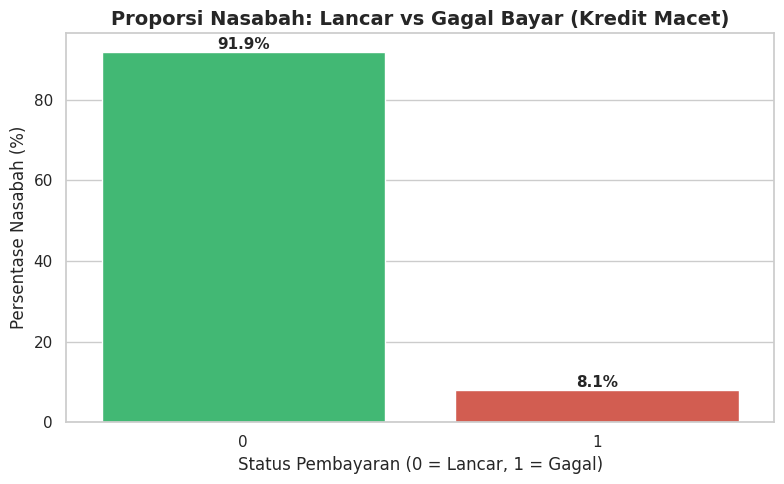

In [17]:
# Import library untuk visualisasi
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Setting tema visual agar grafik terlihat profesional (mirip presentasi bisnis)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Mulai membuat visualisasi data...\n")
df['AGE_YEARS'] = df['DAYS_BIRTH'] / 365
# ==============================================================================
# VISUALISASI 1: Proporsi Target (Lancar vs Gagal Bayar)
# ==============================================================================
plt.figure(figsize=(8, 5))
# Menghitung persentase
target_counts = df['TARGET'].value_counts(normalize=True) * 100

ax = sns.barplot(x=target_counts.index, y=target_counts.values, palette=['#2ecc71', '#e74c3c'])
plt.title('Proporsi Nasabah: Lancar vs Gagal Bayar (Kredit Macet)', fontsize=14, fontweight='bold')
plt.xlabel('Status Pembayaran (0 = Lancar, 1 = Gagal)', fontsize=12)
plt.ylabel('Persentase Nasabah (%)', fontsize=12)

# Menambahkan angka persentase di atas bar
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

/tmp/ipython-input-6698/1771660557.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_default = df.groupby('AGE_GROUP')['TARGET'].mean() * 100


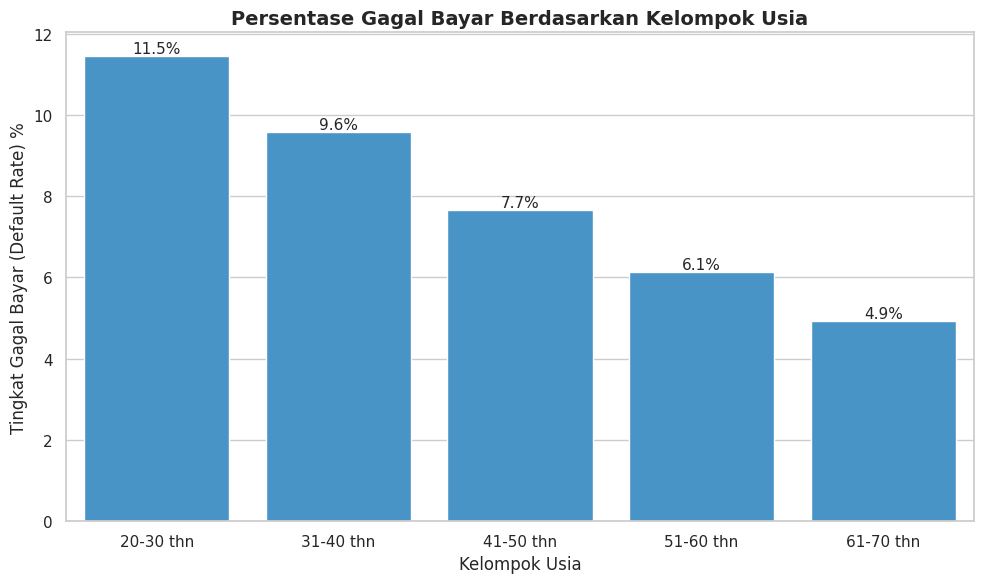

In [18]:
# ==============================================================================
# VISUALISASI 2: Risiko Gagal Bayar Berdasarkan Kelompok Usia
# ==============================================================================
plt.figure(figsize=(10, 6))

# Membuat kategori kelompok usia (Binning)
df['AGE_GROUP'] = pd.cut(df['AGE_YEARS'], bins=[20, 30, 40, 50, 60, 70],
                         labels=['20-30 thn', '31-40 thn', '41-50 thn', '51-60 thn', '61-70 thn'])

# Menghitung rata-rata TARGET (yang sama dengan Default Rate/Persentase Gagal Bayar)
age_default = df.groupby('AGE_GROUP')['TARGET'].mean() * 100

ax2 = sns.barplot(x=age_default.index, y=age_default.values, color='#3498db')
plt.title('Persentase Gagal Bayar Berdasarkan Kelompok Usia', fontsize=14, fontweight='bold')
plt.xlabel('Kelompok Usia', fontsize=12)
plt.ylabel('Tingkat Gagal Bayar (Default Rate) %', fontsize=12)

for p in ax2.patches:
    ax2.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

/tmp/ipython-input-6698/3973881285.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax3 = sns.barplot(y=occ_default.index, x=occ_default.values, palette='Reds_r')


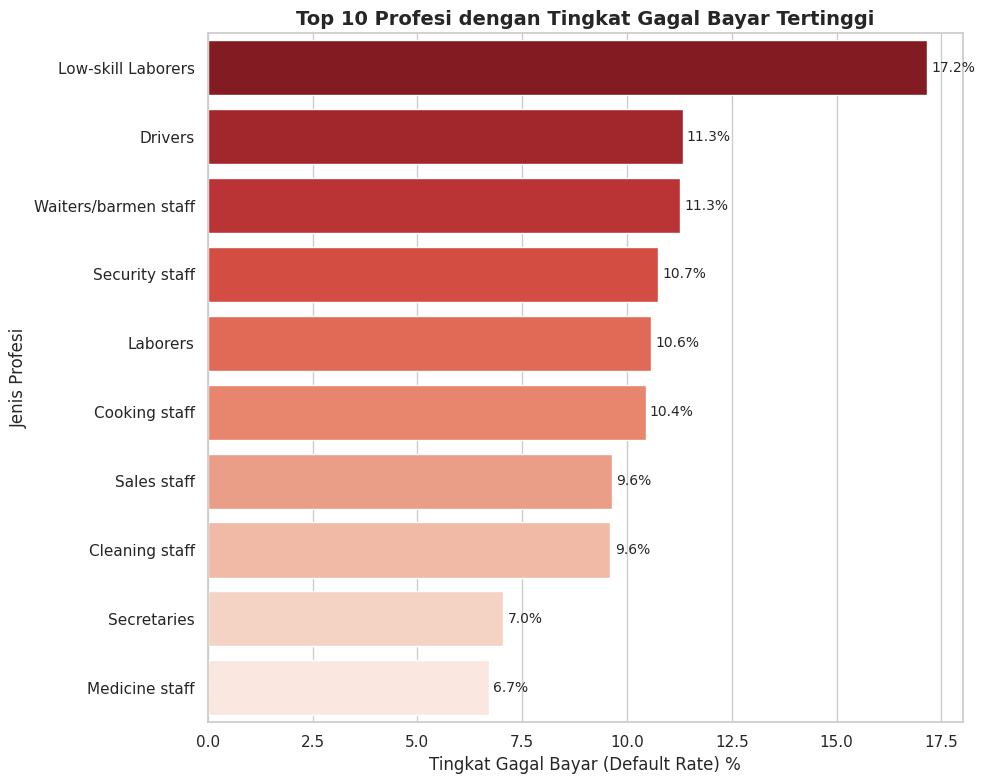


Visualisasi selesai!


In [19]:
# ==============================================================================
# VISUALISASI 3: Top 10 Profesi Paling Berisiko Gagal Bayar
# ==============================================================================
plt.figure(figsize=(10, 8))

# Menghitung default rate per profesi, filter profesi dengan sampel minimal 1000 orang agar valid
occ_counts = df['OCCUPATION_TYPE'].value_counts()
valid_occ = occ_counts[occ_counts > 1000].index

occ_default = df[df['OCCUPATION_TYPE'].isin(valid_occ)].groupby('OCCUPATION_TYPE')['TARGET'].mean() * 100
occ_default = occ_default.sort_values(ascending=False).head(10) # Ambil 10 tertinggi

ax3 = sns.barplot(y=occ_default.index, x=occ_default.values, palette='Reds_r')
plt.title('Top 10 Profesi dengan Tingkat Gagal Bayar Tertinggi', fontsize=14, fontweight='bold')
plt.xlabel('Tingkat Gagal Bayar (Default Rate) %', fontsize=12)
plt.ylabel('Jenis Profesi', fontsize=12)

# Menambahkan angka di sebelah kanan bar
for p in ax3.patches:
    ax3.annotate(f'{p.get_width():.1f}%', (p.get_width() + 0.1, p.get_y() + p.get_height() / 2.),
                 ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.show()

# Hapus kolom AGE_GROUP agar tidak mengganggu model ML nanti
df = df.drop(columns=['AGE_GROUP'])
print("\nVisualisasi selesai!")

In [33]:
# ==============================================================================
# 1. FEATURE ENGINEERING (Membuat Fitur Gabungan)
# ==============================================================================
# Kita buat fitur baru langsung di dalam dataframe df
df['EXT_SOURCE_MEAN'] = df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].mean(axis=1)
df['EXT_SOURCE_MIN'] = df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].min(axis=1)
df['EXT_SOURCE_MAX'] = df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].max(axis=1)
df['EXT_SOURCE_PROD'] = df['EXT_SOURCE_1'] * df['EXT_SOURCE_2'] * df['EXT_SOURCE_3']

print("[1] Fitur gabungan berhasil dibuat (MEAN, MIN, MAX, PROD).\n")

[1] Fitur gabungan berhasil dibuat (MEAN, MIN, MAX, PROD).



In [34]:
# ==============================================================================
# 2. ANALISIS KORELASI MATEMATIS
# ==============================================================================
ext_cols = ['TARGET', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
            'EXT_SOURCE_MEAN', 'EXT_SOURCE_MIN', 'EXT_SOURCE_MAX', 'EXT_SOURCE_PROD']

# Menghitung korelasi khusus untuk kolom-kolom ini
corr_matrix = df[ext_cols].corr()

# Mengambil korelasi fitur-fitur tersebut khusus terhadap kolom TARGET
target_corr = corr_matrix['TARGET'].sort_values()

print("📊 KORELASI DENGAN RISIKO GAGAL BAYAR (TARGET) 📊")
print(target_corr)
print("-" * 50)
print("Catatan: Angka minus (-) berarti korelasi terbalik.")
print("Semakin TINGGI skor eksternalnya, semakin RENDAH risiko gagal bayarnya.\n")

📊 KORELASI DENGAN RISIKO GAGAL BAYAR (TARGET) 📊
EXT_SOURCE_MEAN   -0.220840
EXT_SOURCE_MIN    -0.192750
EXT_SOURCE_PROD   -0.189605
EXT_SOURCE_MAX    -0.174193
EXT_SOURCE_2      -0.160295
EXT_SOURCE_3      -0.155892
EXT_SOURCE_1      -0.098887
TARGET             1.000000
Name: TARGET, dtype: float64
--------------------------------------------------
Catatan: Angka minus (-) berarti korelasi terbalik.
Semakin TINGGI skor eksternalnya, semakin RENDAH risiko gagal bayarnya.



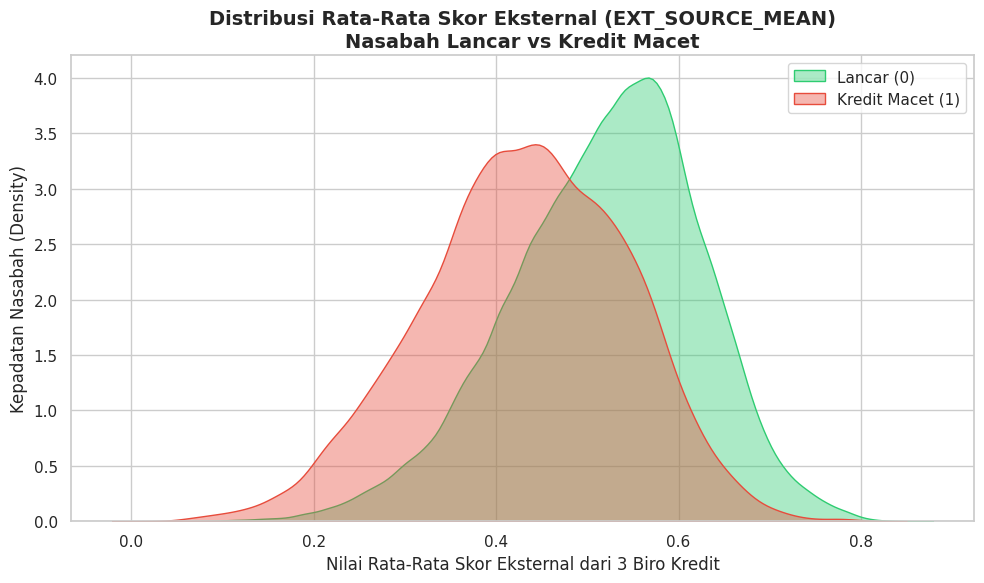

In [35]:
# ==============================================================================
# 3. VISUALISASI DISTRIBUSI (KDE PLOT) UNTUK SLIDE PRESENTASI
# ==============================================================================
plt.figure(figsize=(10, 6))

# Membuat kurva distribusi kepadatan (KDE) untuk membandingkan kedua kelompok
sns.kdeplot(df.loc[df['TARGET'] == 0, 'EXT_SOURCE_MEAN'], label='Lancar (0)', color='#2ecc71', fill=True, alpha=0.4)
sns.kdeplot(df.loc[df['TARGET'] == 1, 'EXT_SOURCE_MEAN'], label='Kredit Macet (1)', color='#e74c3c', fill=True, alpha=0.4)

plt.title('Distribusi Rata-Rata Skor Eksternal (EXT_SOURCE_MEAN)\nNasabah Lancar vs Kredit Macet', fontsize=14, fontweight='bold')
plt.xlabel('Nilai Rata-Rata Skor Eksternal dari 3 Biro Kredit', fontsize=12)
plt.ylabel('Kepadatan Nasabah (Density)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

## DATA TRAINING FOR LOGISTIC REGRESSION

In [20]:
# Import library Machine Learning dari Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("Memulai proses pemodelan Logistic Regression...\n")

Memulai proses pemodelan Logistic Regression...



In [21]:
# ==============================================================================
# 1. PERSIAPAN FITUR (ENCODING)
# ==============================================================================
print("[1] Melakukan One-Hot Encoding pada kolom teks...")
# Menghapus kolom ID karena tidak berguna untuk prediksi
df_model = df.drop(columns=['SK_ID_CURR'])

# Mengubah semua kolom teks menjadi kolom biner (1/0)
# drop_first=True digunakan agar tidak terjadi jebakan multicollinearity
df_encoded = pd.get_dummies(df_model, drop_first=True)
print(f"    -> Jumlah fitur setelah encoding: {df_encoded.shape[1] - 1} kolom\n")

[1] Melakukan One-Hot Encoding pada kolom teks...
    -> Jumlah fitur setelah encoding: 259 kolom



In [22]:
# ==============================================================================
# 2. PEMISAHAN DATA (TRAIN & TEST)
# ==============================================================================
print("[2] Memisahkan data Training (80%) dan Testing (20%)...")
X = df_encoded.drop(columns=['TARGET'])
y = df_encoded['TARGET']

# stratify=y memastikan proporsi 8% gagal bayar tetap terjaga di data train dan test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"    -> Data Training: {X_train.shape[0]} baris")
print(f"    -> Data Testing: {X_test.shape[0]} baris\n")

[2] Memisahkan data Training (80%) dan Testing (20%)...
    -> Data Training: 246008 baris
    -> Data Testing: 61503 baris



In [23]:
# ==============================================================================
# 3. SCALING FITUR (STANDARDIZATION)
# ==============================================================================
print("[3] Melakukan Scaling Data (Standarisasi)...")
scaler = StandardScaler()

# Model belajar dan menyesuaikan skala hanya dari data Training
X_train_scaled = scaler.fit_transform(X_train)
# Data Testing hanya di-transform mengikuti skala Training (mencegah data leakage)
X_test_scaled = scaler.transform(X_test)
print("    -> Scaling selesai.\n")

[3] Melakukan Scaling Data (Standarisasi)...
    -> Scaling selesai.



In [24]:
# ==============================================================================
# 4. PELATIHAN MODEL LOGISTIC REGRESSION
# ==============================================================================
print("[4] Melatih Model Logistic Regression...")
# class_weight='balanced' SANGAT PENTING untuk mengatasi data Imbalanced (8% vs 92%)
logreg_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
logreg_model.fit(X_train_scaled, y_train)
print("    -> Pelatihan model selesai!\n")

[4] Melatih Model Logistic Regression...
    -> Pelatihan model selesai!



In [28]:
from sklearn.metrics import average_precision_score

# Menghitung PR-AUC (Average Precision)
pr_auc = average_precision_score(y_test, y_pred_proba)
print(f"🎯 SKOR PR-AUC: {pr_auc:.4f}")
print("(Sebagai referensi: Jika menebak acak, skor PR-AUC hanya sekitar 0.08 / proporsi kelas 1)")

🎯 SKOR PR-AUC: 0.2334
(Sebagai referensi: Jika menebak acak, skor PR-AUC hanya sekitar 0.08 / proporsi kelas 1)


In [25]:
# ==============================================================================
# 5. EVALUASI MODEL
# ==============================================================================
print("[5] Mengevaluasi Model pada Data Testing...")

# Prediksi probabilitas (Berapa % peluang dia gagal bayar?)
y_pred_proba = logreg_model.predict_proba(X_test_scaled)[:, 1]
# Prediksi kelas akhir (1 atau 0)
y_pred = logreg_model.predict(X_test_scaled)

# Menghitung Metrik Utama: ROC-AUC
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"\n🌟 SKOR ROC-AUC: {roc_auc:.4f} 🌟")
print("Semakin mendekati 1.0, semakin baik modelnya.\n")

# Menampilkan Laporan Klasifikasi
print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred))

[5] Mengevaluasi Model pada Data Testing...

🌟 SKOR ROC-AUC: 0.7499 🌟
Semakin mendekati 1.0, semakin baik modelnya.

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.96      0.69      0.80     56538
           1       0.16      0.68      0.26      4965

    accuracy                           0.69     61503
   macro avg       0.56      0.68      0.53     61503
weighted avg       0.90      0.69      0.76     61503



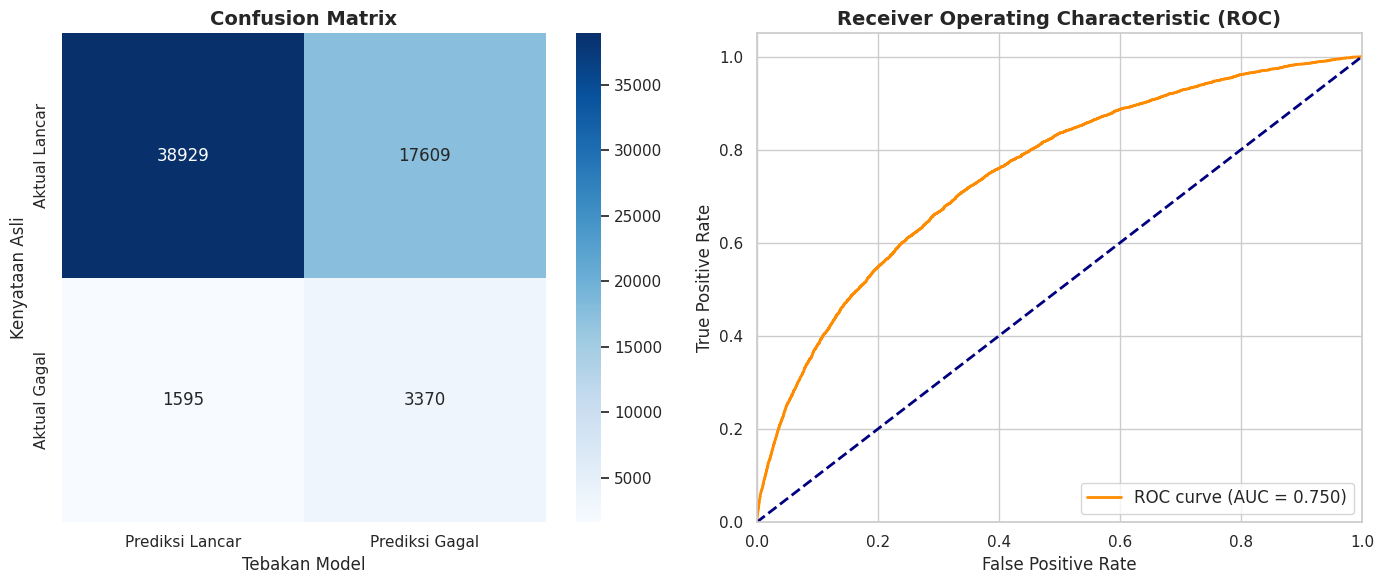

In [26]:
# ==============================================================================
# 6. VISUALISASI EVALUASI (UNTUK SLIDE PRESENTASI)
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# A. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Prediksi Lancar', 'Prediksi Gagal'],
            yticklabels=['Aktual Lancar', 'Aktual Gagal'])
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Tebakan Model')
axes[0].set_ylabel('Kenyataan Asli')

# B. ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('Receiver Operating Characteristic (ROC)', fontsize=14, fontweight='bold')
axes[1].legend(loc="lower right", fontsize=12)

plt.tight_layout()
plt.show()

## DATA TRAINING FOR LightGBM

In [38]:
# Import library LightGBM
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("🚀 Memulai pelatihan model LightGBM...\n")

🚀 Memulai pelatihan model LightGBM...



In [39]:
# ==============================================================================
# 1. INISIALISASI DAN PELATIHAN MODEL
# ==============================================================================
# is_unbalance=True adalah parameter penyeimbang kelas bawaan LightGBM
lgb_model = lgb.LGBMClassifier(
    n_estimators=500,        # Membangun 500 pohon keputusan
    learning_rate=0.05,      # Kecepatan model belajar dari kesalahan
    max_depth=7,             # Mencegah pohon terlalu rumit (mencegah overfitting)
    is_unbalance=True,       # Senjata utama untuk rasio gagal bayar 8%
    random_state=42,
    n_jobs=-1                # Memakai seluruh inti prosesor agar cepat
)

print("[1] Melatih model... (Ini mungkin memakan waktu 1-2 menit)")
# Kita langsung pakai X_train_scaled dari tahap Logistic Regression sebelumnya
lgb_model.fit(X_train_scaled, y_train)
print("    -> Pelatihan LightGBM selesai!\n")

[1] Melatih model... (Ini mungkin memakan waktu 1-2 menit)
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.666094 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9256
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 247
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
    -> Pelatihan LightGBM selesai!



In [40]:
# ==============================================================================
# 2. PREDIKSI DAN EVALUASI
# ==============================================================================
print("[2] Melakukan Prediksi dan Evaluasi Metrik...")
# Menggunakan variabel baru agar tidak tabrakan dengan LogReg
y_pred_proba_lgb = lgb_model.predict_proba(X_test_scaled)[:, 1]
y_pred_lgb = lgb_model.predict(X_test_scaled)

# Menghitung Metrik Pendukung Justifikasi Bisnis
roc_auc_lgb = roc_auc_score(y_test, y_pred_proba_lgb)
pr_auc_lgb = average_precision_score(y_test, y_pred_proba_lgb)

print(f"\n🌟 SKOR ROC-AUC (LightGBM) : {roc_auc_lgb:.4f}")
print(f"🎯 SKOR PR-AUC  (LightGBM) : {pr_auc_lgb:.4f}\n")

print("=== CLASSIFICATION REPORT (LightGBM) ===")
print(classification_report(y_test, y_pred_lgb))

[2] Melakukan Prediksi dan Evaluasi Metrik...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



🌟 SKOR ROC-AUC (LightGBM) : 0.7601
🎯 SKOR PR-AUC  (LightGBM) : 0.2489

=== CLASSIFICATION REPORT (LightGBM) ===
              precision    recall  f1-score   support

           0       0.96      0.73      0.83     56538
           1       0.17      0.66      0.27      4965

    accuracy                           0.72     61503
   macro avg       0.57      0.69      0.55     61503
weighted avg       0.90      0.72      0.78     61503



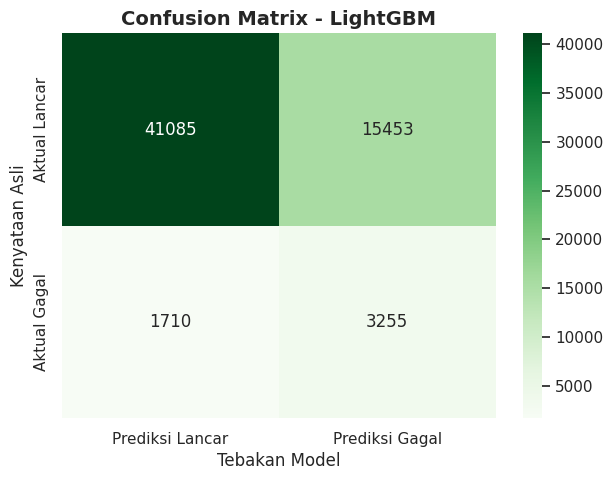

In [32]:
# ==============================================================================
# 3. VISUALISASI CONFUSION MATRIX
# ==============================================================================
plt.figure(figsize=(7, 5))
cm_lgb = confusion_matrix(y_test, y_pred_lgb)
sns.heatmap(cm_lgb, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Prediksi Lancar', 'Prediksi Gagal'],
            yticklabels=['Aktual Lancar', 'Aktual Gagal'])
plt.title('Confusion Matrix - LightGBM', fontsize=14, fontweight='bold')
plt.xlabel('Tebakan Model')
plt.ylabel('Kenyataan Asli')
plt.show()

## FEATURE OF IMPORTANCE

🔍 Menganalisis Feature Importance dari model LightGBM...



/tmp/ipython-input-6698/1477107262.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_15_features, palette='viridis')


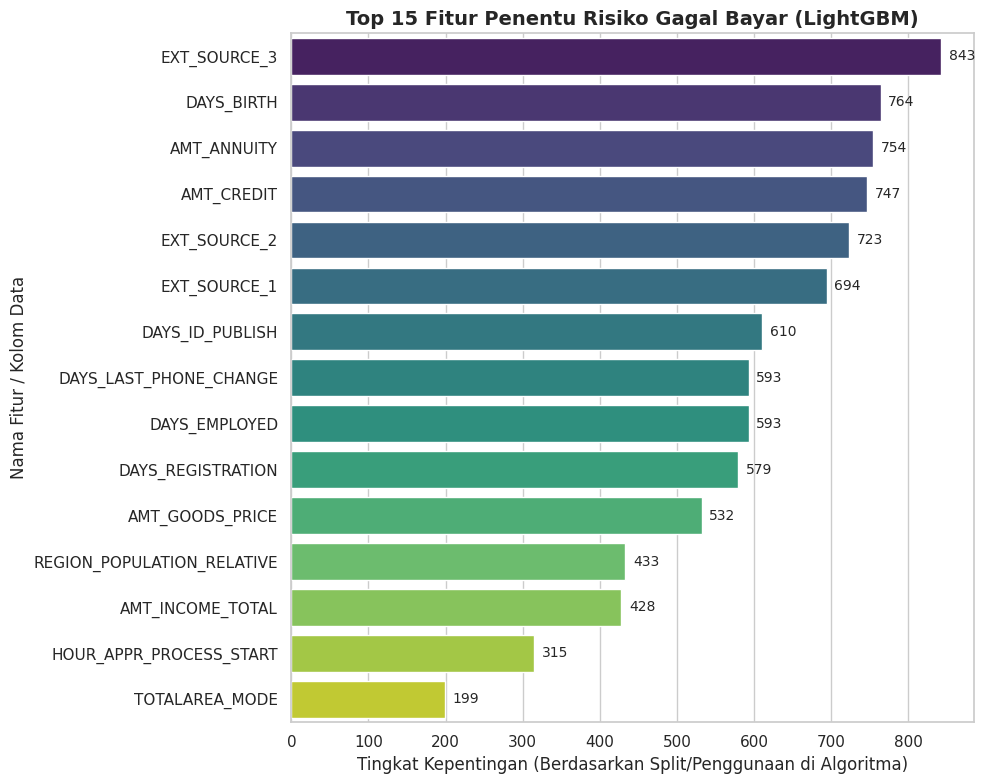

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("🔍 Menganalisis Feature Importance dari model LightGBM...\n")

# 1. Mengambil nama-nama fitur (kolom) dari dataset X yang asli
# (X adalah variabel dari tahap Split Data sebelumnya)
feature_names = X.columns

# 2. Mengambil skor 'importance' yang dihasilkan oleh LightGBM
importances = lgb_model.feature_importances_

# 3. Menggabungkannya ke dalam DataFrame agar mudah diurutkan
feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# 4. Mengurutkan data dan mengambil 15 fitur teratas (Top 15)
top_15_features = feature_imp_df.sort_values(by='Importance', ascending=False).head(15)

# ==============================================================================
# 5. MEMBUAT GRAFIK VISUALISASI
# ==============================================================================
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=top_15_features, palette='viridis')

plt.title('Top 15 Fitur Penentu Risiko Gagal Bayar (LightGBM)', fontsize=14, fontweight='bold')
plt.xlabel('Tingkat Kepentingan (Berdasarkan Split/Penggunaan di Algoritma)', fontsize=12)
plt.ylabel('Nama Fitur / Kolom Data', fontsize=12)

# Menambahkan angka di ujung setiap bar untuk kejelasan
for index, value in enumerate(top_15_features['Importance']):
    plt.text(value + 10, index, str(value), va='center', fontsize=10)

plt.tight_layout()
plt.show()

🚀 Memulai Feature Engineering (Rasio Finansial)...

[1] Fitur CREDIT_TO_ANNUITY_RATIO dan DOWNPAYMENT berhasil dibuat!

📊 KORELASI FITUR BARU DENGAN TARGET 📊
DOWNPAYMENT               -0.033914
CREDIT_TO_ANNUITY_RATIO   -0.032101
TARGET                     1.000000
Name: TARGET, dtype: float64
--------------------------------------------------
Catatan Eksekusi: Fitur ini sekarang sudah menyatu di dataset utama df.
Jika model LightGBM dilatih ulang, ia akan otomatis menggunakan fitur ini.
